In [1]:
# Import dependencies

import numpy as np
from tqdm import tqdm
import multiprocessing as mp
import os
from PIL import Image
import rasterio as rio
import matplotlib.pyplot as plt
import glob
import random
from collections import Counter
import pandas as pd


# Patches and their corresponding AIS labels

In [2]:
# Data path
head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"

patch_dirs = []


# Walk through the directory tree
for root, dirs, files in os.walk(head_dir):
    # Check if this folder has no subfolders (i.e., it's a leaf folder)
    if not dirs:
        # Check if the current folder itself is named 'ship_patches'
        if os.path.basename(root) == 'ship_patches':
            patch_dirs.append(root)


# Print the results
patch_dirs


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082457_HH_4/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082503_HH_5/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082508_HH_6/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082514_HH_7/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082531_HH_10/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_

In [3]:
import re
tif_dir = []
AIS_df  = []
for p_dirsii in patch_dirs:
    tif_dir.append([])  # Add the directory itself to the list
    # Walk through the directory and find all .tif files
    for root, dirs, files in os.walk(p_dirsii):
        AIS_dirii = f"{'/'.join(root.split('/')[:-1])}/AIS.csv"
        AIS_df.append(pd.read_csv(AIS_dirii))

        files = sorted(files, key=lambda x: int(re.search(r'patch_(\d+)', x).group(1)))
        for file in files:
            if file.lower().endswith('.tif'):         
                full_pathii = os.path.join( root, file )
                tif_dir[-1].append( full_pathii )

AIS_df  = pd.concat(AIS_df, ignore_index=True)
tif_dir = [item for sublist in tif_dir for item in sublist]
print(f"Found {len(tif_dir)} patches in {len(patch_dirs)} directories.")

Found 300 patches in 55 directories.


In [4]:
ship_name = AIS_df['Ship type'].tolist()
ship_name

['Dredging',
 'Dredging',
 'Tug',
 'Cargo',
 'Tug',
 'Tug',
 'Other',
 'Passenger',
 'Tanker',
 'Port tender',
 'Cargo',
 'SAR',
 'Dredging',
 'Other',
 'HSC',
 'Other',
 'Tug',
 'Tanker',
 'Tug',
 'HSC',
 'Passenger',
 'Passenger',
 'Passenger',
 'Military',
 'Sailing',
 'Cargo',
 'Fishing',
 'Cargo',
 'Passenger',
 'Other',
 'Tanker',
 'Pilot',
 'Passenger',
 'Cargo',
 'Cargo',
 'Tug',
 'Tanker',
 'Undefined',
 'Military',
 'Tanker',
 'Cargo',
 'Cargo',
 'Passenger',
 'Fishing',
 'Fishing',
 'Cargo',
 'Passenger',
 'Tanker',
 'Fishing',
 'Fishing',
 'Passenger',
 'Fishing',
 'Cargo',
 'Fishing',
 'Fishing',
 'Fishing',
 'Cargo',
 'Passenger',
 'Fishing',
 'Fishing',
 'Cargo',
 'Fishing',
 'Fishing',
 'Cargo',
 'Undefined',
 'Undefined',
 'Dredging',
 'Passenger',
 'Tug',
 'HSC',
 'Tug',
 'Tug',
 'Dredging',
 'Passenger',
 'Port tender',
 'Tug',
 'Passenger',
 'Port tender',
 'Cargo',
 'Other',
 'Dredging',
 'Tug',
 'Tug',
 'Undefined',
 'Cargo',
 'Tanker',
 'Other',
 'Sailing',
 'Car

In [5]:
# Extract unique Ship names and their counts:

# from collections import Counter
# # Count frequency of each prefix
# ship_name_counts = Counter(ship_name)
# ship_name_counts

AIS_df['Ship type'].value_counts()


Ship type
Fishing                  70
Cargo                    54
Passenger                34
Tanker                   28
Tug                      19
Undefined                14
Other                    14
Sailing                  11
Pilot                    11
Dredging                 10
Military                 10
HSC                       9
Port tender               4
Reserved                  3
Pleasure                  3
Law enforcement           2
Towing                    2
SAR                       1
Not party to conflict     1
Name: count, dtype: int64

# Load and Prepare the Data


In [6]:
# Replace classes with "Other Type" if their count is below a threshold:

from collections import Counter

Thresh_class = 30#35#20  # Threshold for minimum class counts

# Count frequency of each ship_name
ship_name_counts = Counter(ship_name)

# Replace ship_name with "Other Type" if their count is below the threshold
ship_name_updated = [p if ship_name_counts[p] >= Thresh_class else "Other Type" for p in ship_name]

In [7]:
# Display the updated ship_name

# Count frequency of each ship_name
ship_name_counts = Counter(ship_name_updated)
ship_name_counts

Counter({'Other Type': 142, 'Fishing': 70, 'Cargo': 54, 'Passenger': 34})

In [8]:
# Labels for each ship_name:

ship_name_label_map = {ship_nameii: idxii+1 for idxii, ship_nameii in enumerate(sorted(ship_name_counts.keys()))}
Labels    = [ship_name_label_map[p] for p in ship_name_updated] # Assigned label to each image


# Reorder the ship_name_label_map to set 'Other Type' as the last label:
ship_name_label_map = {name: idx for idx, name in enumerate(sorted(ship_name_label_map.keys(), key=lambda x: (x == 'Other Type', x)), start=1)}

# Update the Labels list accordingly
Labels = [ship_name_label_map[name] for name in ship_name_updated]

# Display the updated mapping
print(ship_name_label_map)

{'Cargo': 1, 'Fishing': 2, 'Passenger': 3, 'Other Type': 4}


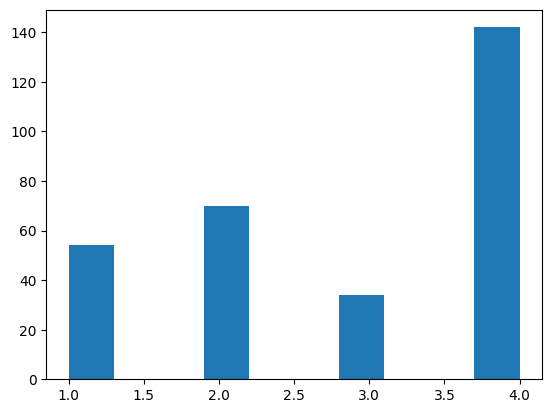

In [9]:
plt.hist(Labels);

## Split Train and Validation samples

In [10]:
from ship_identification_functions import *


In [11]:
tr_samples, val_samples = 0.9, 0. # Ratio of train and validation samples
# tr_samples, val_samples = 15, 0 # Ratio of train and validation samples

tr_label, _, val_label, tr_idx, _, val_idx = tr_te_sample( np.array(Labels), tr_samples, val_samples )

print(f"Training samples: {len(tr_idx)}, Validation samples: {len(val_idx)} [Including 'Other Type']")

# Remove the maximum label (Other Type) from training and validation sets
tr_idx    = tr_idx  [tr_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from training set
tr_label  = tr_label[tr_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from training labels

val_idx   = val_idx  [val_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from validation set
val_label = val_label[val_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from validation labels

print(f"Training samples: {len(tr_idx)}, Validation samples: {len(val_idx)} [Excluding 'Other Type']")

Training samples: 268, Validation samples: 32 [Including 'Other Type']
Training samples: 141, Validation samples: 17 [Excluding 'Other Type']


In [12]:
im_path_tr  = [tif_dir[ii] for ii in tr_idx]
im_path_val = [tif_dir[ii] for ii in val_idx]

im_path_tr

['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082542_HH_12/ship_patches/NovaSAR_01_53540_grd_13_240411_082542_HH_12_patch_15_Fishing.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53611_grd_240415_215644_HH/NovaSAR_01_53611_grd_13_240415_215713_HH_6/ship_patches/NovaSAR_01_53611_grd_13_240415_215713_HH_6_patch_1_Passenger.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53873_grd_240502_084940_HH/NovaSAR_01_53873_grd_13_240502_084957_HH_4/ship_patches/NovaSAR_01_53873_grd_13_240502_084957_HH_4_patch_5_Passenger.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53789_grd_240427_082056_HH/NovaSAR_01_53789_grd_13_240427_082153_HH_11/ship_patches/NovaSAR_01_53789_grd_13_240427_082153_HH_11_patch_8_Fishing.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53611_grd_240415_215644_HH/NovaSAR_01_53611_grd_13_240

In [13]:
for zz in range(0, 20):
    print(zz)
    print(f"tr_idx (zz): {tr_idx[zz]}")
    print(f"tr_label (zz): {tr_label[zz]}")
    print(tif_dir[tr_idx[zz]])

0
tr_idx (zz): 61
tr_label (zz): 2
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082542_HH_12/ship_patches/NovaSAR_01_53540_grd_13_240411_082542_HH_12_patch_15_Fishing.tif
1
tr_idx (zz): 177
tr_label (zz): 3
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53611_grd_240415_215644_HH/NovaSAR_01_53611_grd_13_240415_215713_HH_6/ship_patches/NovaSAR_01_53611_grd_13_240415_215713_HH_6_patch_1_Passenger.tif
2
tr_idx (zz): 272
tr_label (zz): 3
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53873_grd_240502_084940_HH/NovaSAR_01_53873_grd_13_240502_084957_HH_4/ship_patches/NovaSAR_01_53873_grd_13_240502_084957_HH_4_patch_5_Passenger.tif
3
tr_idx (zz): 247
tr_label (zz): 2
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53789_grd_240427_082056_HH/NovaSAR_01_53789_grd_13_240427_082153_HH_11/ship_patches/NovaSAR_01_53789_grd_13_240427_082153_HH_11_patch_8_Fishing.

In [14]:
for zz in range(110, 120):
    print(zz)
    print(f"Labels[{zz}]: {Labels[zz]}")
    print(tif_dir[zz])

110
Labels[110]: 2
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53605_grd_240415_084739_HH/NovaSAR_01_53605_grd_13_240415_084842_HH_12/ship_patches/NovaSAR_01_53605_grd_13_240415_084842_HH_12_patch_6_Fishing.tif
111
Labels[111]: 1
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53605_grd_240415_084739_HH/NovaSAR_01_53605_grd_13_240415_084842_HH_12/ship_patches/NovaSAR_01_53605_grd_13_240415_084842_HH_12_patch_7_Cargo.tif
112
Labels[112]: 2
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53605_grd_240415_084739_HH/NovaSAR_01_53605_grd_13_240415_084842_HH_12/ship_patches/NovaSAR_01_53605_grd_13_240415_084842_HH_12_patch_8_Fishing.tif
113
Labels[113]: 2
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53605_grd_240415_084739_HH/NovaSAR_01_53605_grd_13_240415_084847_HH_13/ship_patches/NovaSAR_01_53605_grd_13_240415_084847_HH_13_patch_1_Fishing.tif
114
Labels[114]: 2
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2

In [15]:
# Class weights for imbalanced dataset:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on frequency of each class in tr_label
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(tr_label),
    y=tr_label
) 

class_weights

array([0.97916667, 0.74603175, 1.56666667])

### Dataloader

In [16]:
torch.__version__


'2.7.1+cu118'

In [17]:
# Define image dimensions, batch size, and number of classes:

batch_size  = 8# 32 #16#4 #64#
N_classes   = max(tr_label)  # Number of classes for one-hot encoding

In [18]:
tr_images  = load_images_to_memory(im_path_tr)
val_images = load_images_to_memory(im_path_val)

Loading images: 100%|██████████| 17/17 [00:00<00:00, 51.38it/s]


In [19]:
# Create datasets and dataloaders:

# tr_dataset     = ShipDataset(im_path_tr, labels=tr_label)
# val_dataset    = ShipDataset(im_path_val, labels=val_label)

tr_dataset     = ShipDatasetMemory(tr_images, labels=tr_label)
val_dataset    = ShipDatasetMemory(val_images, labels=val_label)

tr_dataloader  = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Example:
X, y = next(iter(val_dataloader))
print(f"images shape for a batch       : {X.shape}")
print(f"GT (label) shape for a batch   : {y.shape}")
y

images shape for a batch       : torch.Size([8, 1, 512, 512])
GT (label) shape for a batch   : torch.Size([8, 3])


tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.]])

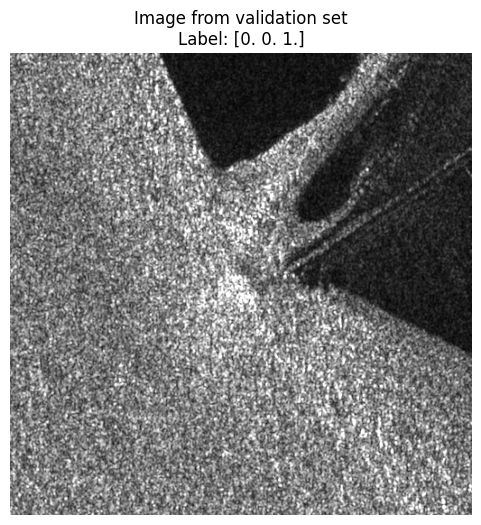

In [20]:

plt.figure(figsize=(6, 6))
plt.imshow(X.cpu().detach().numpy()[0, 0], cmap='gray')
plt.title(f"Image from validation set\nLabel: {y[0].numpy()}")
plt.axis('off')
plt.show()

# Train the Model 

In [21]:
# Load dependencies
import torch
import torch.nn.functional as F
from torch import nn, optim
from torchvision import models, transforms
import timm
from torchinfo import summary

# Define processing device:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


cuda:0


In [22]:
# https://towardsdatascience.com/getting-started-with-pytorch-image-models-timm-a-practitioners-guide-4e77b4bf9055
timm.list_models('*')

['aimv2_1b_patch14_224',
 'aimv2_1b_patch14_336',
 'aimv2_1b_patch14_448',
 'aimv2_3b_patch14_224',
 'aimv2_3b_patch14_336',
 'aimv2_3b_patch14_448',
 'aimv2_huge_patch14_224',
 'aimv2_huge_patch14_336',
 'aimv2_huge_patch14_448',
 'aimv2_large_patch14_224',
 'aimv2_large_patch14_336',
 'aimv2_large_patch14_448',
 'bat_resnext26ts',
 'beit3_base_patch16_224',
 'beit3_giant_patch14_224',
 'beit3_giant_patch14_336',
 'beit3_large_patch16_224',
 'beit_base_patch16_224',
 'beit_base_patch16_384',
 'beit_large_patch16_224',
 'beit_large_patch16_384',
 'beit_large_patch16_512',
 'beitv2_base_patch16_224',
 'beitv2_large_patch16_224',
 'botnet26t_256',
 'botnet50ts_256',
 'caformer_b36',
 'caformer_m36',
 'caformer_s18',
 'caformer_s36',
 'cait_m36_384',
 'cait_m48_448',
 'cait_s24_224',
 'cait_s24_384',
 'cait_s36_384',
 'cait_xs24_384',
 'cait_xxs24_224',
 'cait_xxs24_384',
 'cait_xxs36_224',
 'cait_xxs36_384',
 'coat_lite_medium',
 'coat_lite_medium_384',
 'coat_lite_mini',
 'coat_lite_sma

## Model Architecture

In [23]:
from deep_functions import *

In [24]:
img_dim = X.cpu().numpy().shape[1:]  # Get image dimensions from the batch
print(f"Image dimensions: {img_dim}")

Image dimensions: (1, 512, 512)


In [25]:
# Define 2D-CNN (for comparison):
FC_neurons = [64, 32,16] # [256, 64, 32] 
# FC_neurons = [256, 128, 32, 16] 

BackBone_args                  = {}
BackBone_args['model_name']    = 'resnet18'#'densenet121'#'resnet50'
BackBone_args['pretrained']    = True
BackBone_args['features_only'] = True


cnnBB = CNNBackBone( model_name   = BackBone_args['model_name'],
                    in_channels   = img_dim[0],
                    pretrained    = BackBone_args['pretrained'],
                    features_only = BackBone_args['features_only']
                    ).to(device)
FC_input_dim = cnnBB( torch.randn(batch_size, img_dim[0], img_dim[1], img_dim[2]).to(device=device) ).shape[1]

# cnnBB = '' # No backbone

model_CNN  = CNN( in_channels   = img_dim[0],
                  num_classes   = N_classes,
                  BackBone      = cnnBB,
                  FC_input_dim  = FC_input_dim,
                  FC_neurons    = FC_neurons
               ).to(device)
model_CNN.train()  # Set model to training mode
print( summary( model_CNN, input_size=(1, img_dim[0], img_dim[1], img_dim[2]) ) )

Layer (type:depth-idx)                             Output Shape              Param #
CNN                                                [1, 1, 1, 1]              --
├─CBAM: 1-1                                        [1, 1, 512, 512]          --
│    └─ChannelAttention: 2-1                       [1, 1, 512, 512]          --
│    │    └─AdaptiveAvgPool2d: 3-1                 [1, 1, 1, 1]              --
│    │    └─Sequential: 3-2                        [1, 1, 1, 1]              2
│    │    └─AdaptiveMaxPool2d: 3-3                 [1, 1, 1, 1]              --
│    │    └─Sequential: 3-4                        [1, 1, 1, 1]              (recursive)
│    │    └─Sigmoid: 3-5                           [1, 1, 1, 1]              --
│    └─SpatialAttention: 2-2                       [1, 1, 512, 512]          --
│    │    └─Conv2d: 3-6                            [1, 1, 512, 512]          18
│    │    └─Sigmoid: 3-7                           [1, 1, 512, 512]          --
├─CNNBackBone: 1-2         

## Training

In [26]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights_tensor)

Class weights: tensor([0.9792, 0.7460, 1.5667], device='cuda:0')


In [27]:
reps = 4  # Number of repetitions for training to ensure robustness
num_epochs = 50 # 25#200
learning_rate = 15*1e-5

criterion = torch.nn.BCEWithLogitsLoss(weight=class_weights_tensor)  # For multi-label one-hot targets
# criterion = torch.nn.CrossEntropyLoss()#)

optimizer = torch.optim.Adam(model_CNN.parameters(), lr=learning_rate)
# optimizer = torch.optim.SGD(model_CNN.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, 
)

# gamma = 0.95  # Decay rate, adjust as needed (e.g., 0.95 means lr = lr * 0.95 each epoch)
# exp_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

In [28]:
# Training loop for model_CNN using tr_dataloader and val_dataloader

loss_history = {}  # To store training and validation losses
loss_history['train'] = []
loss_history['val']   = []
loss_condition_min = np.inf
for repii in range(reps):  # Repeat training for robustness

    optimizer = torch.optim.Adam(model_CNN.parameters(), lr=learning_rate)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, 
    )

    for epoch in range(num_epochs):
        model_CNN.train()
        train_loss = 0.0
        for X_batch, y_batch in tr_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            if X_batch.shape[0] != 1:
                optimizer.zero_grad()
                outputs = model_CNN(X_batch)["classifier"]
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(tr_dataloader.dataset)

        model_CNN.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_dataloader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                outputs = model_CNN(X_val)["classifier"]
                loss = criterion(outputs, y_val)
                val_loss += loss.item() * X_val.size(0)
        val_loss /= len(val_dataloader.dataset)
        scheduler.step(val_loss)
        # exp_scheduler.step()
        # loss_condition = (2*val_loss + 2*train_loss)/4  # Combined loss condition
        loss_condition = 1*val_loss + 0*train_loss  # Combined loss condition
        if loss_condition <= loss_condition_min:

            print(f"Repeat {repii+1}: Epoch {epoch+1:3.0f}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} --> Loss condition decreased!")
            loss_condition_min = loss_condition
            # Save the model if validation loss improves
            best_weights = model_CNN.state_dict()
            torch.save(best_weights, "model_CNN_temp_weights.pth")
        else:
            print(f"Repeat {repii+1}: Epoch {epoch+1:3.0f}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            if epoch % 1 == 0:
                model_CNN.load_state_dict( torch.load("model_CNN_temp_weights.pth", map_location=device) )
        
        
        loss_history['train'].append(train_loss)
        loss_history['val'].append(val_loss)
        
    model_CNN.load_state_dict( torch.load("model_CNN_temp_weights.pth", map_location=device) )

    model_CNN.eval()
    train_loss = 0.0
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in tr_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_CNN(X_batch)["classifier"]
            loss = criterion(outputs, y_batch)
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(tr_dataloader.dataset)
            
        for X_val, y_val in val_dataloader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model_CNN(X_val)["classifier"]
            loss = criterion(outputs, y_val)
            val_loss += loss.item() * X_val.size(0)
        val_loss /= len(val_dataloader.dataset)
        print(f"\nLOADING THE BEST WEIGHTS in Repeat {repii+1}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}\n\n")


Repeat 1: Epoch   1/50 | Train Loss: 0.9043 | Val Loss: 1.2085 --> Loss condition decreased!
Repeat 1: Epoch   2/50 | Train Loss: 0.8160 | Val Loss: 0.9724 --> Loss condition decreased!
Repeat 1: Epoch   3/50 | Train Loss: 0.7546 | Val Loss: 0.8423 --> Loss condition decreased!
Repeat 1: Epoch   4/50 | Train Loss: 0.7236 | Val Loss: 0.7993 --> Loss condition decreased!
Repeat 1: Epoch   5/50 | Train Loss: 0.7035 | Val Loss: 0.7869 --> Loss condition decreased!
Repeat 1: Epoch   6/50 | Train Loss: 0.6878 | Val Loss: 0.7790 --> Loss condition decreased!
Repeat 1: Epoch   7/50 | Train Loss: 0.6724 | Val Loss: 0.8371
Repeat 1: Epoch   8/50 | Train Loss: 0.6627 | Val Loss: 0.8204
Repeat 1: Epoch   9/50 | Train Loss: 0.6650 | Val Loss: 0.8202
Repeat 1: Epoch  10/50 | Train Loss: 0.6648 | Val Loss: 0.8083
Repeat 1: Epoch  11/50 | Train Loss: 0.6669 | Val Loss: 0.8238
Repeat 1: Epoch  12/50 | Train Loss: 0.6613 | Val Loss: 0.8216
Repeat 1: Epoch  13/50 | Train Loss: 0.6645 | Val Loss: 0.8289
R

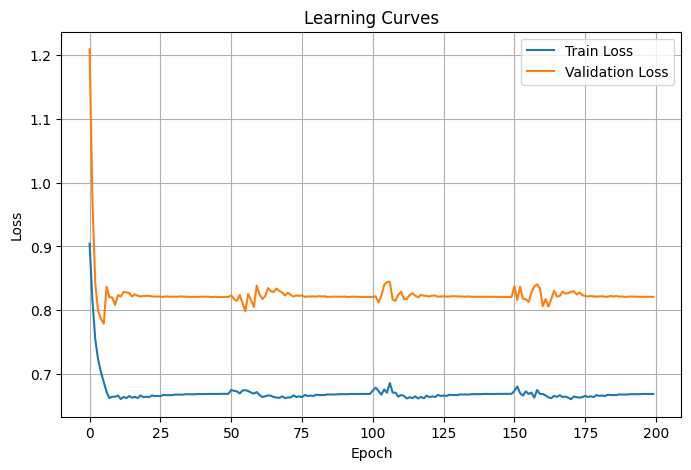

In [29]:
# Plot learning curves for training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history['train'], label='Train Loss')
plt.plot(loss_history['val'], label='Validation Loss') 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score
import torch

# Inference on training set
model_CNN.eval()
y_true_tr = []
y_pred_tr = []

with torch.no_grad():
    for X_batch, y_batch in tr_dataloader:
        X_batch = X_batch.to(device)
        outputs = model_CNN(X_batch)["classifier"]
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = torch.argmax(y_batch, dim=1).cpu().numpy()
        y_true_tr.extend(labels)
        y_pred_tr.extend(preds)

# Inference on validation set
y_true_val = []
y_pred_val = []

with torch.no_grad():
    for X_batch, y_batch in val_dataloader:
        X_batch = X_batch.to(device)
        outputs = model_CNN(X_batch)["classifier"]
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = torch.argmax(y_batch, dim=1).cpu().numpy()
        y_true_val.extend(labels)
        y_pred_val.extend(preds)

# Confusion matrices and Overall Accuracy
cm_tr = confusion_matrix(y_true_tr, y_pred_tr)
oa_tr = accuracy_score(y_true_tr, y_pred_tr)
cm_val = confusion_matrix(y_true_val, y_pred_val)
oa_val = accuracy_score(y_true_val, y_pred_val)

print("Train Confusion Matrix:\n", cm_tr)
print("Train Overall Accuracy:", oa_tr)
print("Validation Confusion Matrix:\n", cm_val)
print("Validation Overall Accuracy:", oa_val)

Train Confusion Matrix:
 [[ 8  6 34]
 [10 32 21]
 [ 4  7 19]]
Train Overall Accuracy: 0.41843971631205673
Validation Confusion Matrix:
 [[3 2 1]
 [3 3 1]
 [1 1 2]]
Validation Overall Accuracy: 0.47058823529411764


conf_mat_pr.max: 71.11111450195312
Data Evaluation:
              precision    recall  f1-score   support

           0       0.36      0.17      0.23        48
           1       0.71      0.51      0.59        63
           2       0.26      0.63      0.37        30

    accuracy                           0.42       141
   macro avg       0.44      0.44      0.40       141
weighted avg       0.50      0.42      0.42       141



,Results
OA,41.843971
Kappa,16.034858
BA,43.597884
Pr,44.383474
F1,39.551621


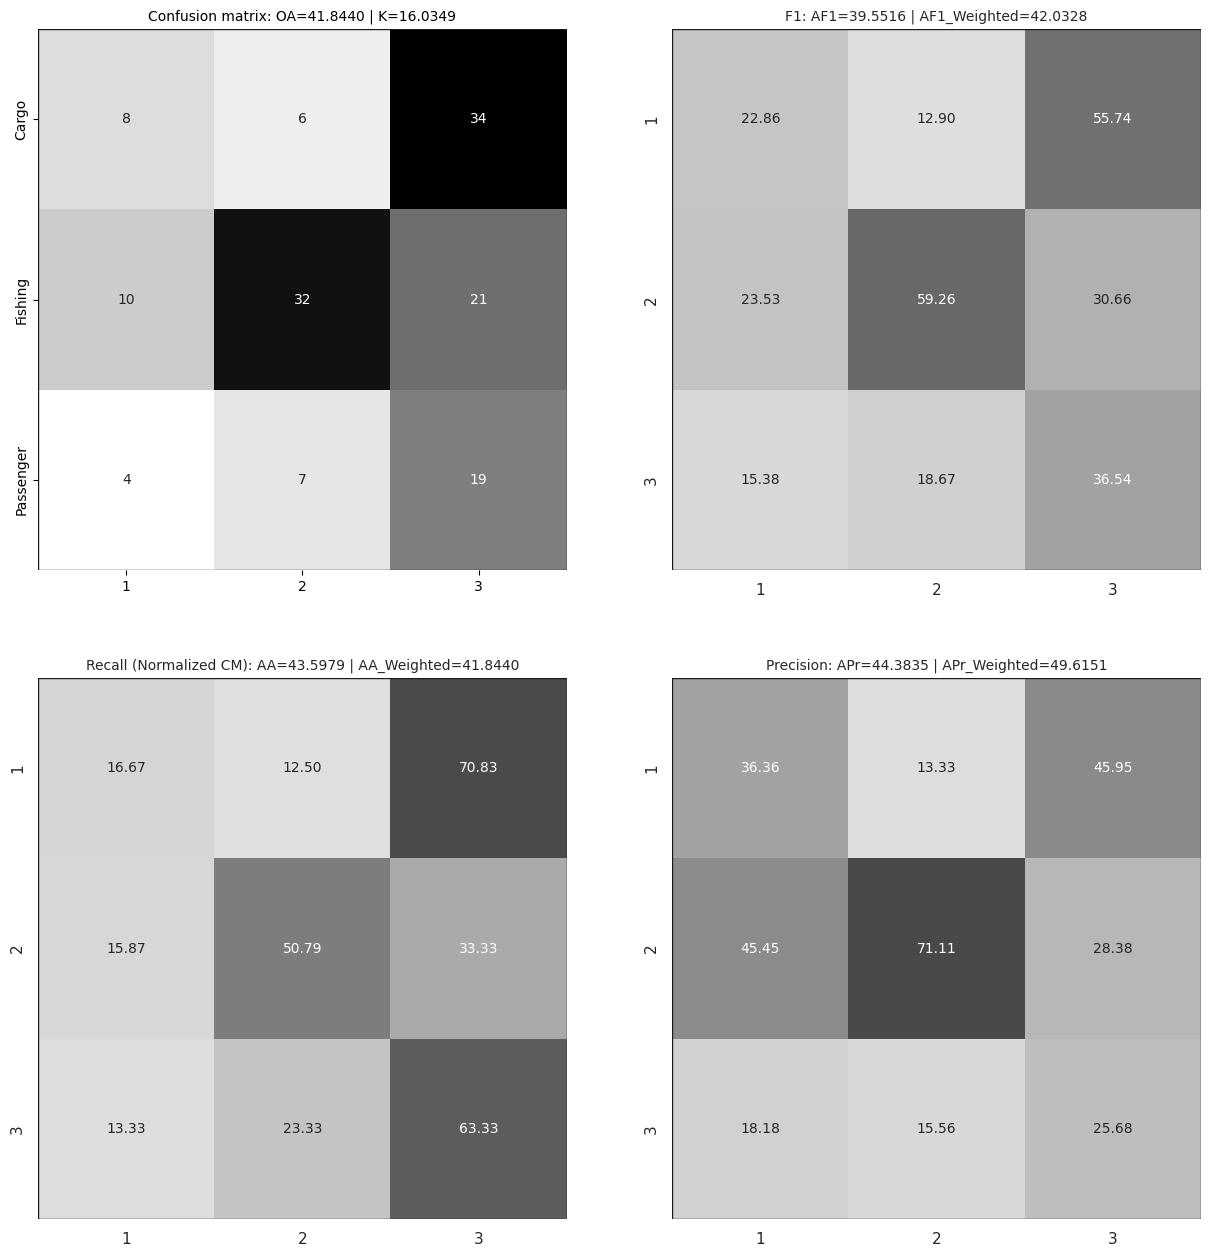

In [31]:
CM_zz = confusion_mat(y_true_tr, y_pred_tr, list(ship_name_label_map.keys())[:-1], plot=True,cmap="gray_r")